In [2]:
!pip install prophet

     ---------------------------------------- 0.0/50.3 kB ? eta -:--:--
     --------------- ---------------------- 20.5/50.3 kB 640.0 kB/s eta 0:00:01
     ------------------------------ ------- 41.0/50.3 kB 653.6 kB/s eta 0:00:01
     -------------------------------------- 50.3/50.3 kB 646.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.1 MB 1.1 MB/s eta 0:00:12
    --------------------------------------- 0.2/12.1 MB 2.4 MB/s eta 0:00:06
   - -------------------------------------- 0.4/12.1 MB 2.7 MB/s eta 0:00:05
   -- ------------------------------------- 0.7/12.1 MB 3.8 MB/s eta 0:00:04
   --- ------------------------------------ 1.1/12.1 MB 5.1 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/12.1 MB 8.0 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.1 MB 7.1 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.1 MB 9.4 MB/s eta 0:00:01
  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose


In [5]:
#correct the path of the dataset
data_path="Tesla.csv"
df=pd.read_csv(data_path)

df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [7]:
#checing fro missing values
missing_values = df.isnull().sum()

#basic statistical details
statistics = df.describe()

missing_values, statistics

(Date         0
 Open         0
 High         0
 Low          0
 Close        0
 Volume       0
 Adj Close    0
 dtype: int64,
               Open         High          Low        Close        Volume  \
 count  1692.000000  1692.000000  1692.000000  1692.000000  1.692000e+03   
 mean    132.441572   134.769698   129.996223   132.428658  4.270741e+06   
 std      94.309923    95.694914    92.855227    94.313187  4.295971e+06   
 min      16.139999    16.629999    14.980000    15.800000  1.185000e+05   
 25%      30.000000    30.650000    29.215000    29.884999  1.194350e+06   
 50%     156.334999   162.370002   153.150002   158.160004  3.180700e+06   
 75%     220.557495   224.099999   217.119999   220.022503  5.662100e+06   
 max     287.670013   291.420013   280.399994   286.040009  3.716390e+07   
 
          Adj Close  
 count  1692.000000  
 mean    132.428658  
 std      94.313187  
 min      15.800000  
 25%      29.884999  
 50%     158.160004  
 75%     220.022503  
 max     28

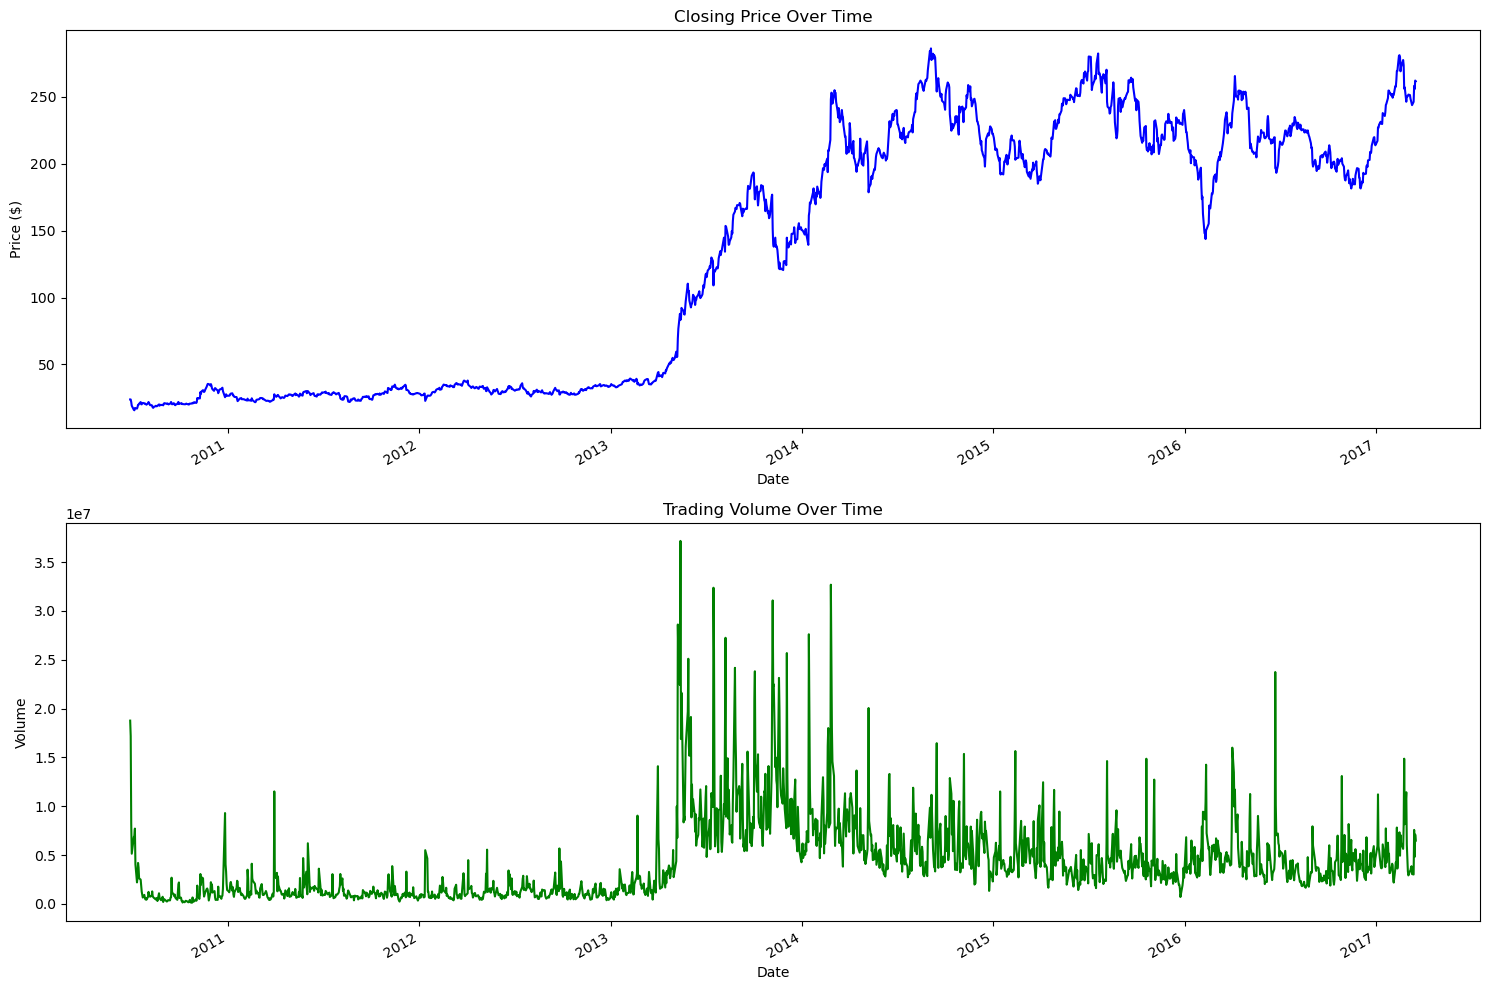

In [8]:
import matplotlib.pyplot as plt

#convert the 'date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

#set the date as the index of the dataframe for plotting 
df.set_index('Date', inplace=True)

#create a figure and a set of subplots
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,10))


# Plot the closing price over time
df['Close'].plot(ax=ax[0], color='blue')
ax[0].set_title('Closing Price Over Time')
ax[0].set_ylabel('Price ($)')

# Plot the trading volume over time
df['Volume'].plot(ax=ax[1], color='green')
ax[1].set_title('Trading Volume Over Time')
ax[1].set_ylabel('Volume')

# Improve layout
plt.tight_layout()
plt.show()



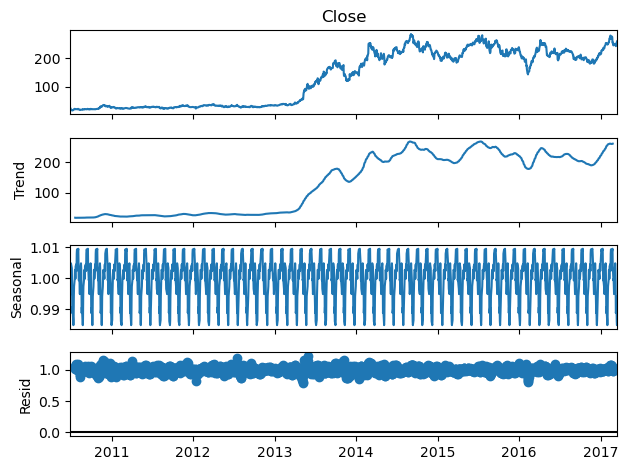

In [9]:
# Seasonality Analysis
decomposition = seasonal_decompose(df['Close'], model='multiplicative', period=30)
fig = decomposition.plot()
plt.show()

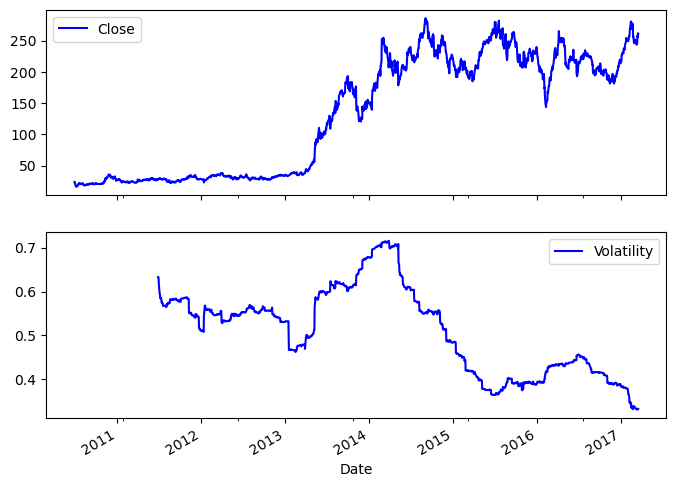

In [10]:
# Volatility Analysis
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(window=252).std() * np.sqrt(252)
df[['Close', 'Volatility']].plot(subplots=True, color='blue', figsize=(8, 6))
plt.show()

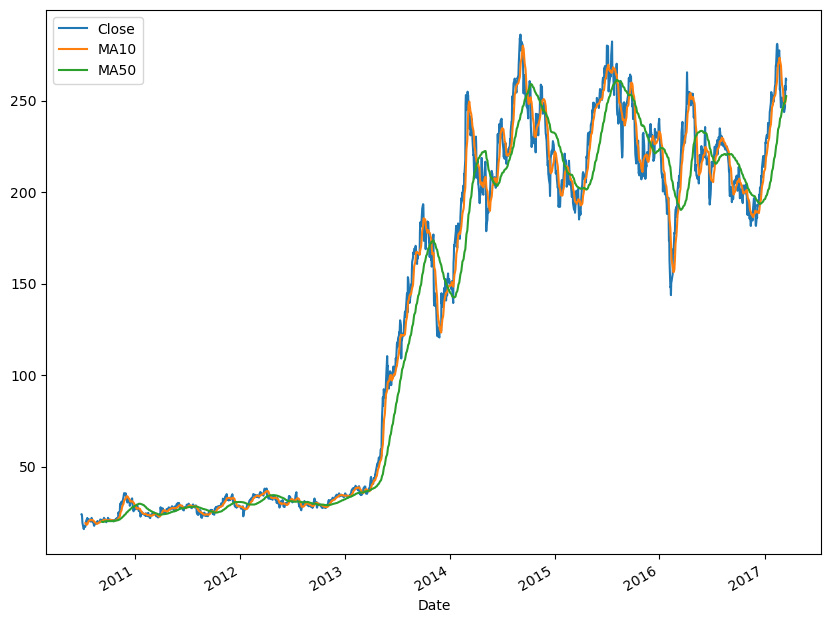

In [11]:
# Moving Average Analysis
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df[['Close','MA10','MA50']].plot(label='Tesla', figsize=(10,8))
plt.show()

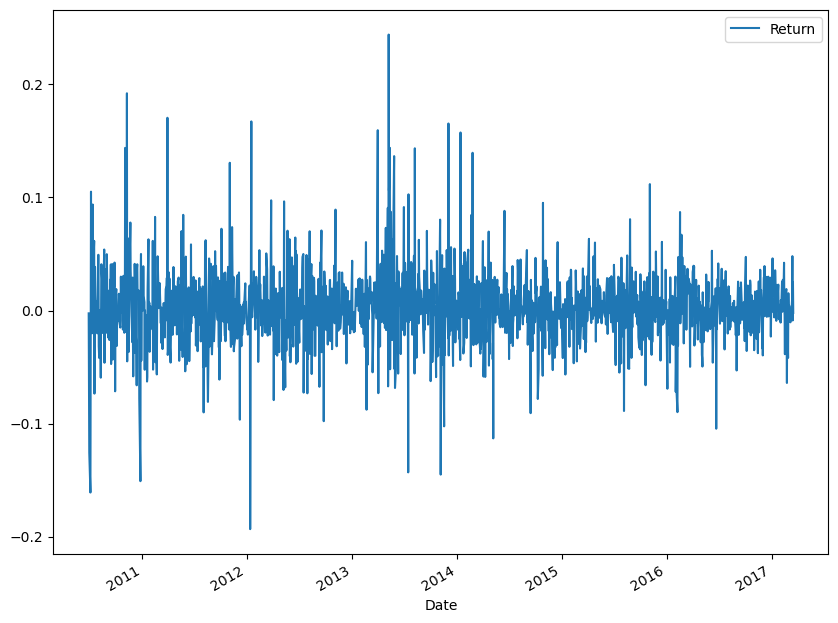

In [12]:
# Return Analysis
df['Return'] = df['Close'].pct_change()
df[['Return']].plot(label='Return', figsize=(10,8))
plt.show()

In [13]:
# Prepare the data for Prophet
prophet_df = df.reset_index()[['Date', 'Close']]
prophet_df.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)

prophet_df.head()

,ds,y
0,2010-06-29,23.889999
1,2010-06-30,23.830000
2,2010-07-01,21.959999
3,2010-07-02,19.200001
4,2010-07-06,16.110001


In [14]:
# Initialize the Prophet model
model = Prophet()

In [15]:
# Fit the model to the data
model.fit(prophet_df)

# Specify the number of days for predictions
future = model.make_future_dataframe(periods=365)

# Use the model to make predictions
forecast = model.predict(future)

18:41:12 - cmdstanpy - INFO - Chain [1] start processing
18:41:12 - cmdstanpy - INFO - Chain [1] done processing


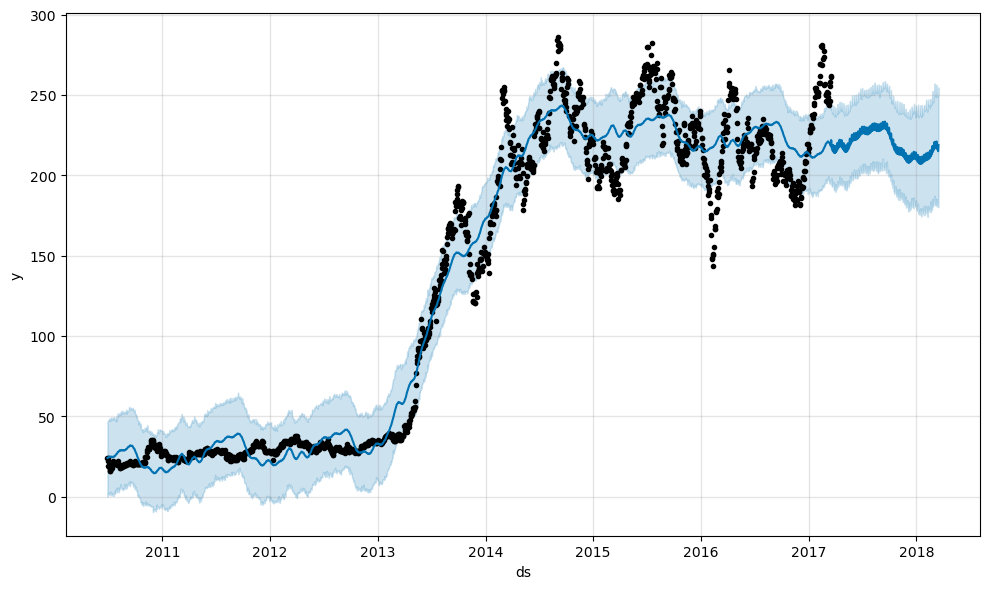

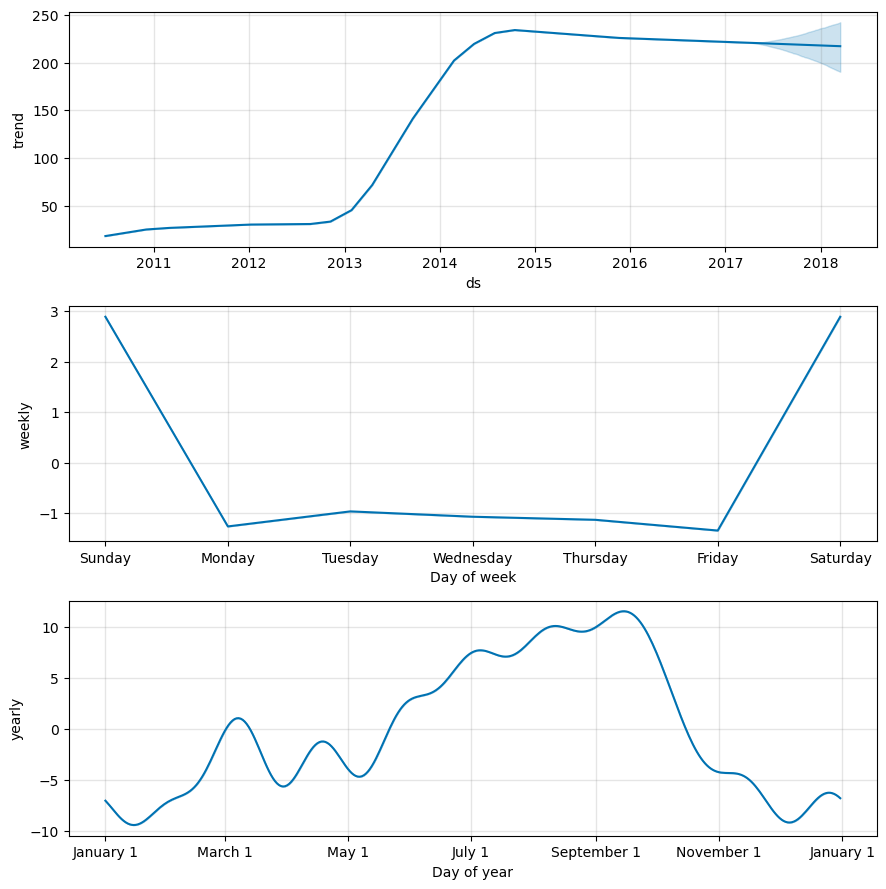

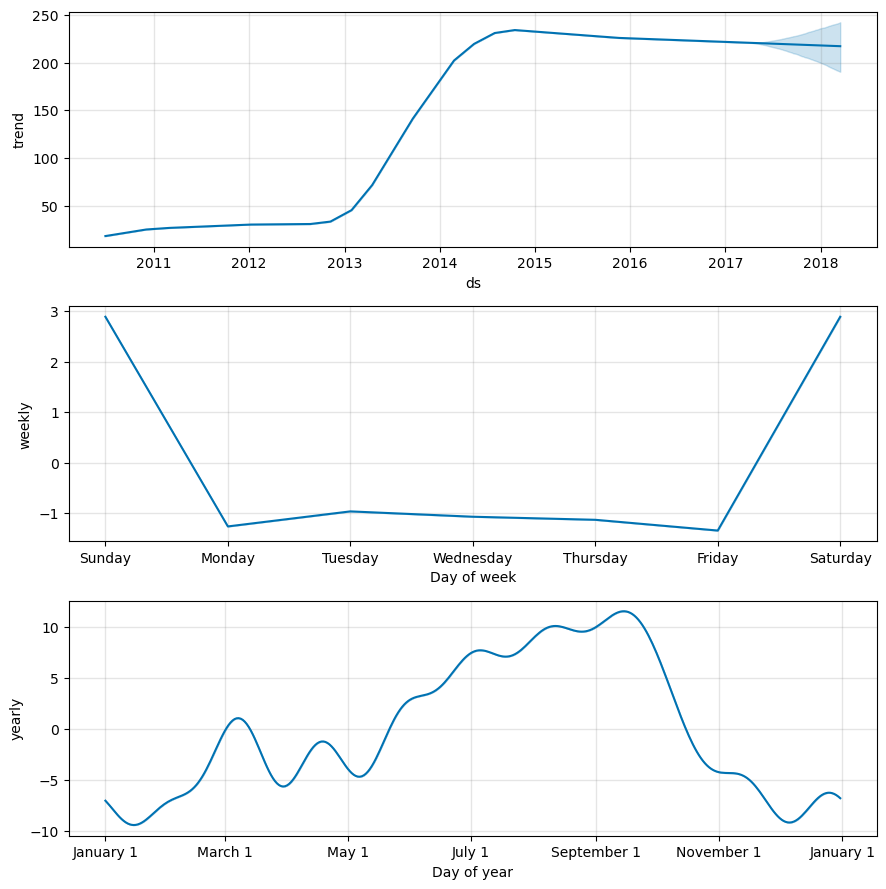

In [16]:
# Visualize the forecast
model.plot(forecast)
plt.show()

# If you want to see the components of the forecast, you can use:
model.plot_components(forecast)

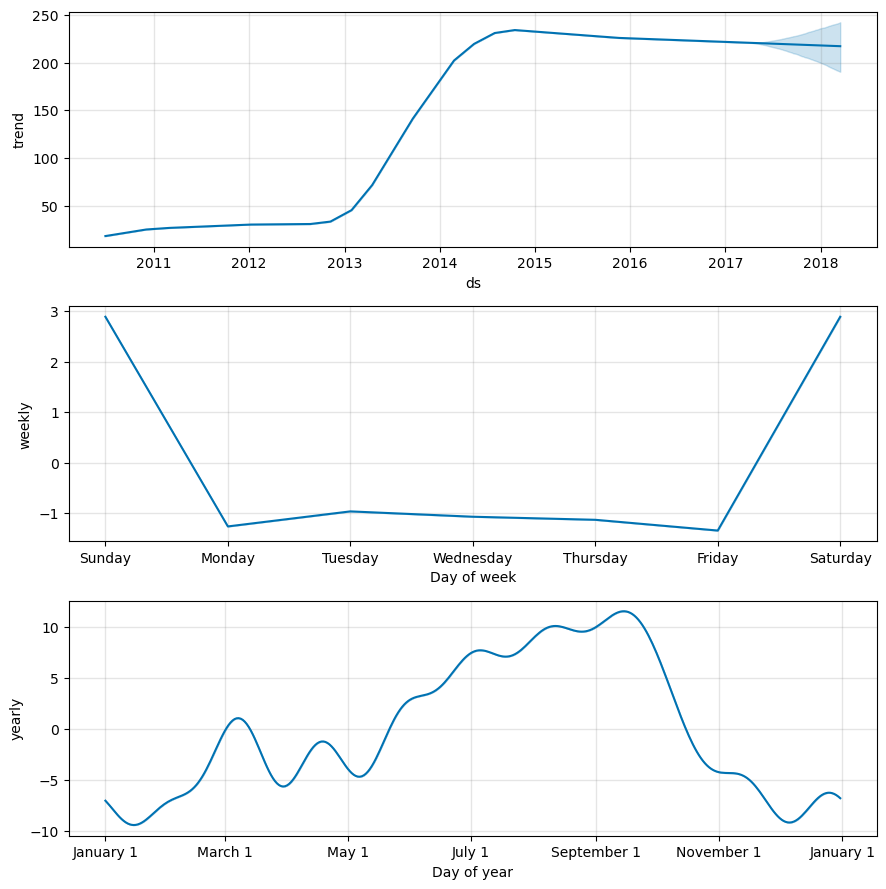

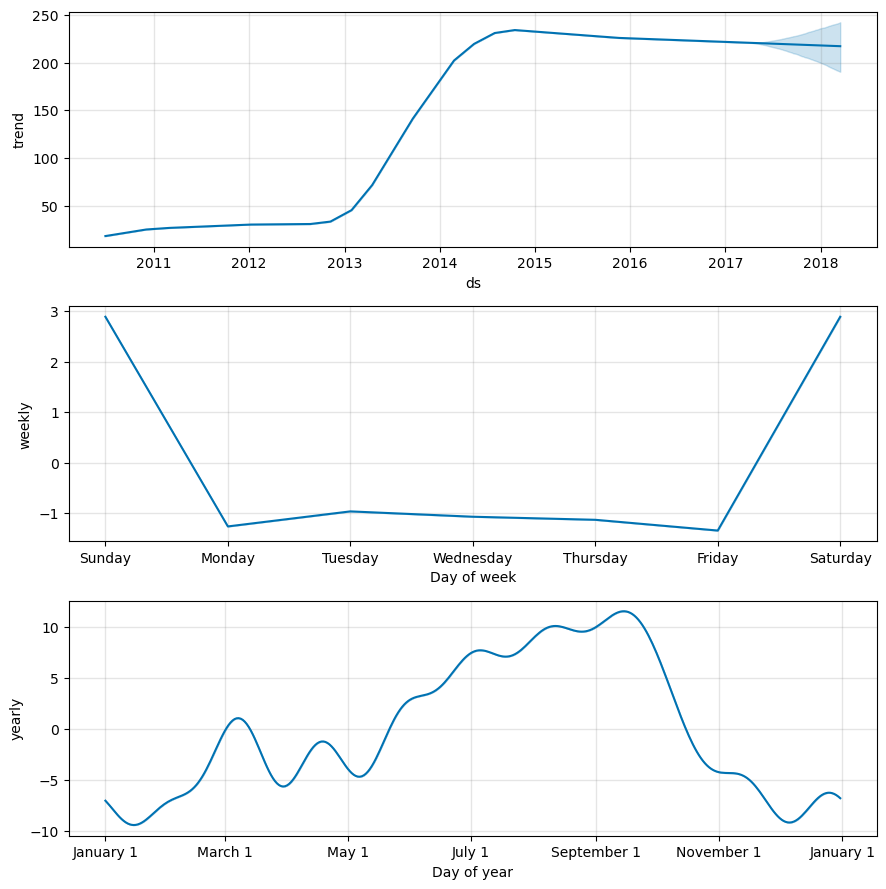

In [18]:
model.plot_components(forecast)